In [2]:
import os
print(os.path.exists(r"C:\Windows\System32\vcruntime140_1.dll"))

True


In [3]:
import sys
print(sys.executable)

C:\Users\User\Miniconda\envs\orttest\python.exe



0: 640x448 1 FACE, 24.7ms
Speed: 10.8ms preprocess, 24.7ms inference, 8.0ms postprocess per image at shape (1, 3, 640, 448)
Detections(xyxy=array([[     9.7063,      12.244,      67.106,        98.4]], dtype=float32), mask=None, confidence=array([    0.79878], dtype=float32), class_id=array([0]), tracker_id=None, data={'class_name': array(['FACE'], dtype='<U4')}, metadata={})


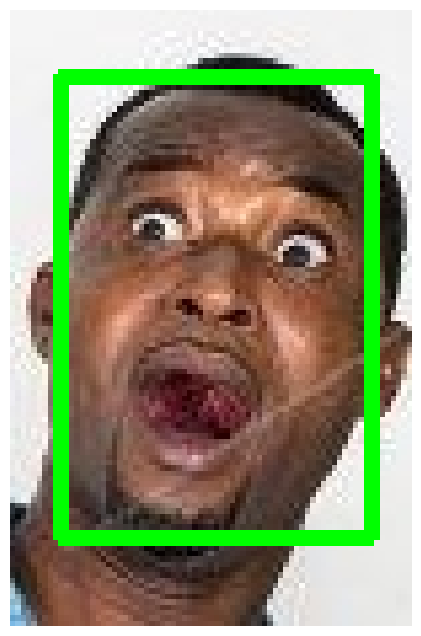

In [4]:
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
from PIL import Image
from supervision import Detections
import cv2
import matplotlib.pyplot as plt

# Download model from Hugging Face
model_path = hf_hub_download(
    repo_id="arnabdhar/YOLOv8-Face-Detection",
    filename="model.pt"
)

# Load model
model = YOLO(model_path)

# Run inference
image_path = r"D:\fer2013 + affectnet\fer2013+affectnet\fearful\afraid_African_214.jpg"
output = model(Image.open(image_path))

# Convert to supervision detections
results = Detections.from_ultralytics(output[0])
print(results)

# Read original image with cv2
image = cv2.imread(image_path)

# Draw bounding boxes
for box in results.xyxy:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Convert BGR to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(8, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [5]:
import os
from pathlib import Path

import cv2
import numpy as np
from PIL import Image
from huggingface_hub import hf_hub_download
from ultralytics import YOLO



# 1. Settings

folder_path = r"C:\Users\User\.cache\kagglehub\datasets\shahzadabbas\expression-in-the-wild-expw-dataset\versions\1\origin"


padding_ratio = 0.15   # 15% padding around the box

# Confidence threshold to ignore weak detections
conf_threshold = 0.25

# Supported image extensions
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}



# 2. Load YOLO face model

model_path = hf_hub_download(
    repo_id="arnabdhar/YOLOv8-Face-Detection",
    filename="model.pt"
)
model = YOLO(model_path)



# 3. Helper functions

def choose_best_face(boxes, confs):
    """
    Choose the best face using area * confidence.
    Prefers large, confident detections.
    """
    best_idx = None
    best_score = -1

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        w = max(0, x2 - x1)
        h = max(0, y2 - y1)
        area = w * h
        conf = confs[i] if confs is not None else 0.6
        score = area * conf

        if score > best_score:
            best_score = score
            best_idx = i

    return best_idx


def add_padding_and_clip(x1, y1, x2, y2, img_w, img_h, pad_ratio=0.15):
    """
    Add padding to a bounding box and clip it to image boundaries.
    """
    w = x2 - x1
    h = y2 - y1

    pad_x = int(w * pad_ratio)
    pad_y = int(h * pad_ratio)

    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(img_w, x2 + pad_x)
    y2 = min(img_h, y2 + pad_y)

    return x1, y1, x2, y2


def process_image(image_path, model, conf_threshold=0.25, padding_ratio=0.15):
    """
    Detect faces in one image.
    - If no face: delete image
    - If faces found: choose best one, crop, overwrite original
    Returns a status string.
    """
    try:
        pil_img = Image.open(image_path).convert("RGB")
    except Exception as e:
        return f"ERROR opening image: {e}"

    # Run inference
    results = model(pil_img, verbose=False)
    result = results[0]

    # Read with cv2 for cropping/saving
    image = cv2.imread(str(image_path))
    if image is None:
        return "ERROR reading image with cv2"

    img_h, img_w = image.shape[:2]

    # Extract boxes/confidences
    if result.boxes is None or len(result.boxes) == 0:
        os.remove(image_path)
        return "DELETED - no face"

    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy() if result.boxes.conf is not None else None

    # Filter by confidence threshold
    filtered_boxes = []
    filtered_confs = []

    for i, box in enumerate(boxes):
        conf = confs[i] if confs is not None else 1.0
        if conf >= conf_threshold:
            filtered_boxes.append(box)
            filtered_confs.append(conf)

    if len(filtered_boxes) == 0:
        os.remove(image_path)
        return "DELETED - no face above confidence threshold"

    filtered_boxes = np.array(filtered_boxes)
    filtered_confs = np.array(filtered_confs)

    # Choose best face
    best_idx = choose_best_face(filtered_boxes, filtered_confs)
    x1, y1, x2, y2 = filtered_boxes[best_idx]

    # Convert to ints
    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

    # Add padding and keep inside image
    x1, y1, x2, y2 = add_padding_and_clip(
        x1, y1, x2, y2, img_w, img_h, pad_ratio=padding_ratio
    )

    # Validate crop
    if x2 <= x1 or y2 <= y1:
        os.remove(image_path)
        return "DELETED - invalid crop"

    cropped = image[y1:y2, x1:x2]

    if cropped.size == 0:
        os.remove(image_path)
        return "DELETED - empty crop"

    # Overwrite original image
   # Convert OpenCV (BGR) → PIL (RGB)
    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    cropped_pil = Image.fromarray(cropped_rgb)
    
    best_conf = filtered_confs[best_idx]
    message = f"CROPPED - conf={best_conf:.3f}"
    
    return cropped_pil, message



# # 4. Process entire folder

# folder = Path(folder_path)

# if not folder.exists():
#     print(f"Folder does not exist: {folder}")
# else:
#     image_files = [p for p in folder.iterdir() if p.suffix.lower() in valid_exts]
#     print(f"Found {len(image_files)} image(s)")

#     cropped_count = 0
#     deleted_count = 0
#     error_count = 0

#     for i, image_path in enumerate(image_files, start=1):
#         status = process_image(
#             image_path=image_path,
#             model=model,
#             conf_threshold=conf_threshold,
#             padding_ratio=padding_ratio,
#         )

#         print(f"[{i}/{len(image_files)}] {image_path.name} -> {status}")

#         if status.startswith("CROPPED"):
#             cropped_count += 1
#         elif status.startswith("DELETED"):
#             deleted_count += 1
#         else:
#             error_count += 1

#     print("\nDone.")
#     print(f"Cropped: {cropped_count}")
#     print(f"Deleted: {deleted_count}")
#     print(f"Errors:  {error_count}")

In [7]:
import os

folder = r"C:\Users\User\.cache\kagglehub\datasets\shahzadabbas\expression-in-the-wild-expw-dataset\versions\1\origin"

file_count = 0

for root, dirs, files in os.walk(folder):
    file_count += len(files)

print("Total files:", file_count)

Total files: 0


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [9]:
train_dir = r"D:\fer2013 + affectnet\expression-in-the-wild-expw-dataset\expw full dataset\train"
test_dir  = r"D:\fer2013 + affectnet\expression-in-the-wild-expw-dataset\expw full dataset\test"

In [9]:
train_dir = r"D:\fer2013 + affectnet\DATASET\train"
test_dir  = r"D:\fer2013 + affectnet\DATASET\test"

In [10]:
import torch
import torch.nn as nn
from torchvision import models

class EmotionResNet(nn.Module):
    def __init__(self, num_classes, freeze_backbone=False):
        super().__init__()

        # Switch to ResNet34
        self.backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

        in_features = self.backbone.fc.in_features

        # Improved head
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

        # Optional freezing
        if freeze_backbone:
            for name, param in self.backbone.named_parameters():
                if not name.startswith("fc"):
                    param.requires_grad = False

    def forward(self, x):
        return self.backbone(x)

In [11]:
from torchvision import transforms

res_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

res_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [12]:
res_train_dataset = datasets.ImageFolder(train_dir, transform=res_train_transform)
res_test_dataset = datasets.ImageFolder(test_dir, transform=res_val_transform)

# split train_dataset into 85% train and 15% validation
res_train_size = int(0.85 * len(res_train_dataset))
res_val_size = len(res_train_dataset) - res_train_size

res_train_subset, res_val_subset = random_split(
    res_train_dataset,
    [res_train_size, res_val_size],
    generator=torch.Generator().manual_seed(42)   # reproducible split
)

In [13]:
res_train_loader = DataLoader(res_train_subset, batch_size=64, shuffle=True, num_workers=2)
res_val_loader   = DataLoader(res_val_subset, batch_size=64, shuffle=False, num_workers=2)
res_test_loader = DataLoader(res_test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [14]:
from tqdm import tqdm
import torch

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 7
model = EmotionResNet(num_classes=num_classes, freeze_backbone=True).to(device)

# Freeze backbone (train only the classifier first)
for name, param in model.backbone.named_parameters():
    if not name.startswith("fc"):
        param.requires_grad = False
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=1e-5, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=1
)

In [16]:
model.load_state_dict(torch.load("C:/Users/User/OneDrive/Documents/resNET emotion recognition/best_resnet34.pth", map_location=device))

<All keys matched successfully>

In [17]:
num_epochs = 50
best_val_acc = 0.0

patience = 6
counter = 0  # counts epochs without improvement

for epoch in range(num_epochs):

    # UNFREEZE BACKBONE
    if epoch == 4:
        for param in model.backbone.parameters():
            param.requires_grad = True
            
            backbone_params = [
            p for name, p in model.backbone.named_parameters()
            if not name.startswith("fc.")
        ]

        head_params = list(model.backbone.fc.parameters())

        optimizer = torch.optim.AdamW([
                    {"params": backbone_params, "lr": 1e-5},
                    {"params": head_params, "lr": 1e-4},
                ], weight_decay=5e-4)
        print("Backbone unfrozen. Switched to fine-tuning.")

    # TRAIN 
    train_loss, train_acc = train_one_epoch(
        model, res_train_loader, criterion, optimizer, device
    )

    # VALIDATE 
    val_loss, val_acc = evaluate(
        model, res_val_loader, criterion, device
    )

    # PRINT
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # CHECK IMPROVEMENT
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0  # reset counter

        torch.save(
            model.state_dict(),
            "C:/Users/User/OneDrive/Documents/resNET emotion recognition/best_resnet34_justRAF.pth"
        )
        print("✅ Best model saved!")

    else:
        counter += 1
        print(f"No improvement for {counter} epoch(s)")

    # ---- EARLY STOPPING ----
    if counter >= patience:
        print("⛔ Early stopping triggered.")
        break


Epoch [1/50]
Train Loss: 0.6749 | Train Acc: 0.9094
Val   Loss: 0.7420 | Val   Acc: 0.8734
✅ Best model saved!



Epoch [2/50]
Train Loss: 0.6739 | Train Acc: 0.9081
Val   Loss: 0.7356 | Val   Acc: 0.8745
✅ Best model saved!



Epoch [3/50]
Train Loss: 0.6784 | Train Acc: 0.9052
Val   Loss: 0.7414 | Val   Acc: 0.8680
No improvement for 1 epoch(s)


KeyboardInterrupt: 

In [18]:
import torch

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# recreate your model exactly
model = EmotionResNet(num_classes=7).to(device)   # replace with your actual ResNet class

# load best saved weights
model.load_state_dict(torch.load(
    r"C:/Users/User/OneDrive/Documents/resNET emotion recognition/best_resnet34.pth",
    map_location=device
))

# evaluation mode
model.eval()

EmotionResNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [19]:
from tqdm.notebook import tqdm # use: from tqdm import tqdm if not in notebook

def test_model(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Testing", dynamic_ncols=True):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / total
    test_acc = correct / total

    return test_loss, test_acc, all_labels, all_preds

In [20]:
test_loss, test_acc, all_labels, all_preds = test_model(
    model, res_test_loader, criterion, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc:  {test_acc:.4f}")

Testing:   0%|                                                                                  | 0/48 [00:00<…

Test Loss: 0.8088
Test Acc:  0.8389


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)
class_names = res_test_loader.dataset.classes

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [ ]:
import torch
from PIL import Image

@torch.no_grad()
def predict_single_image(image, model, transform, device):
    model.eval()

    if isinstance(image, str):
        image = Image.open(image).convert("RGB")

    input_tensor = transform(image).unsqueeze(0).to(device)
    outputs = model(input_tensor)

    probs = torch.softmax(outputs, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()
    confidence = probs[0, pred_idx].item()

    return pred_idx, confidence

In [51]:
from torchvision import transforms

res_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [52]:
from PIL import Image
import torch

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get class names
CLASS_NAMES = res_test_dataset.classes

# Load image
image_path = r"D:\fer2013 + affectnet\DATASET\test\angry\test_1309_aligned.jpg"
img = Image.open(image_path).convert("RGB")

# Transform
input_tensor = res_val_transform(img).unsqueeze(0).to(DEVICE)

# Model
model.to(DEVICE)
model.eval()

# Predict
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)

    pred_idx = torch.argmax(probs, dim=1).item()
    conf = probs[0, pred_idx].item()

print(f"Prediction: {CLASS_NAMES[pred_idx]} ({conf:.3f})")

Prediction: happy (0.764)


In [53]:
pred_idx, conf = predict_single_image(
    result_img,   # PIL image
    emotion_model,
    emotion_transform,
    DEVICE
)

NameError: name 'result_img' is not defined

In [1]:
import tkinter as tk
from tkinter import Label, Button
from PIL import Image, ImageTk
from tkinterdnd2 import DND_FILES, TkinterDnD
import os
import torch


# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get class names from ImageFolder
CLASS_NAMES = res_test_dataset.classes

# Put emotion model on device once
model.to(DEVICE)
model.eval()


class ImageDropApp:
    def __init__(self, root, face_model):
        self.root = root
        self.face_model = face_model
        self.root.title("Drag and Drop Image")
        self.root.geometry("600x750")

        self.image_path = None

        # Drop area 
        self.drop_label = Label(
            root,
            text="Drag and drop an image here",
            relief="ridge",
            bd=2,
            bg="lightgray"
        )
        self.drop_label.pack(padx=20, pady=10, fill="both", expand=True)

        self.drop_label.drop_target_register(DND_FILES)
        self.drop_label.dnd_bind("<<Drop>>", self.drop_image)

        # ---- Original image ----
        self.original_label = Label(root, text="Original Image")
        self.original_label.pack()

        self.original_image_label = Label(root)
        self.original_image_label.pack(pady=5)

        #Analyse button
        self.analyse_button = Button(
            root,
            text="Analyse",
            command=self.analyse_image,
            bg="blue",
            fg="white"
        )
        self.analyse_button.pack(pady=10)

        # ---- Processed image ----
        self.result_label = Label(root, text="Processed Image")
        self.result_label.pack()

        self.result_image_label = Label(root)
        self.result_image_label.pack(pady=5)

        # ---- Prediction text ----
        self.prediction_label = Label(root, text="Prediction: None", font=("Arial", 14, "bold"))
        self.prediction_label.pack(pady=10)

        self.tk_original = None
        self.tk_result = None

    # Handle drop
    def drop_image(self, event):
        file_path = event.data.strip("{}")

        if file_path.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp")):
            self.image_path = file_path

            image = Image.open(file_path).convert("RGB")
            image.thumbnail((400, 400))
            self.tk_original = ImageTk.PhotoImage(image)

            self.original_image_label.config(image=self.tk_original)
            self.original_image_label.image = self.tk_original

            self.drop_label.config(text=os.path.basename(file_path))
            self.prediction_label.config(text="Prediction: None")
        else:
            self.drop_label.config(text="Invalid image file")

    # Analyse button action
    def analyse_image(self):
        if self.image_path is None:
            self.drop_label.config(text="Drop an image first!")
            return

        # Crop face with YOLO
        output = process_image(
            self.image_path,
            self.face_model,
            conf_threshold=0.25,
            padding_ratio=0.15
        )

        # Handle crop output
        if isinstance(output, tuple):
            result_img, message = output
            self.drop_label.config(text=message)
        elif isinstance(output, str):
            self.drop_label.config(text=output)
            self.prediction_label.config(text="Prediction: None")
            return
        else:
            result_img = output

        # Transform cropped image exactly like validation/test
        input_tensor = res_val_transform(result_img).unsqueeze(0).to(DEVICE)

        # Predict with emotion classifier
        with torch.no_grad():
            outputs = model(input_tensor)
            probs = torch.softmax(outputs, dim=1)

            pred_idx = torch.argmax(probs, dim=1).item()
            conf = probs[0, pred_idx].item()

        pred_text = f"Prediction: {CLASS_NAMES[pred_idx]} ({conf:.3f})"
        print(pred_text)
        self.prediction_label.config(text=pred_text)

        # Display cropped image
        display_img = result_img.copy()
        display_img.thumbnail((400, 400))
        self.tk_result = ImageTk.PhotoImage(display_img)

        self.result_image_label.config(image=self.tk_result)
        self.result_image_label.image = self.tk_result


#  MAIN
if __name__ == "__main__":
    root = TkinterDnD.Tk()

    model_path = hf_hub_download(
        repo_id="arnabdhar/YOLOv8-Face-Detection",
        filename="model.pt"
    )
    face_model = YOLO(model_path)

    app = ImageDropApp(root, face_model)
    root.mainloop()

NameError: name 'res_test_dataset' is not defined